In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
# === Configure for your domain — update these before running ===

DOMAIN = "ANT27"
FORCING = "ERA5"
PROJECT_NAME = f"{DOMAIN}_{FORCING}"

VARS = ["evap", "ff10m", "precip", "sndiv", "snowfall", "snowmelt", "tskin"]

SCRATCH = os.environ.get("SCRATCH", "")

TS_START_YEAR  = 1979    # first year of timeseries
TS_END_YEAR    = 2025    # last year of timeseries
AVE_START_YEAR = 1979    # first year of spinup averaging period
AVE_END_YEAR   = 2020    # last year of spinup averaging period
NUM_LONG_BANDS = 17      # number of longitude-band parts
CELL_WIDTH     = 15      # rlon grid cells per part

# Derived paths — mirror config.py
BASE_DIR  = Path(SCRATCH) / PROJECT_NAME
YEARS_DIR = BASE_DIR / "process-RACMO" / f"years-{TS_START_YEAR}"
FILES_DIR = BASE_DIR / "input" / "timeseries"
AVE_DIR   = BASE_DIR / "input" / "averages"

print(f"Domain:     {DOMAIN} / {FORCING}")
print(f"Timeseries: {TS_START_YEAR}–{TS_END_YEAR}")
print(f"Averages:   {AVE_START_YEAR}–{AVE_END_YEAR}")
print(f"Lon bands:  {NUM_LONG_BANDS} × {CELL_WIDTH} cells")
print(f"Base dir:   {BASE_DIR}")

## QAQC checks

Four automated checks:
1. **File completeness** — every expected yearly, timeseries, and average file exists
2. **Time axis integrity** — timeseries spans the correct years, is monotonic, has no duplicates
3. **NaN check** — no NaN values anywhere (RACMO covers the full domain)
4. **Spatial coverage** — each timeseries lon-band part has the correct `rlon` width and parts tile the grid contiguously

Run the cell below to execute all checks. For the NaN check, adjust `sample_parts` if you want to check more than the first and last part.

In [ ]:
# ── Helper: expected file paths ───────────────────────────────────────────────

def _yr_fname(var, year):
    return YEARS_DIR / f"{var}_{PROJECT_NAME}_forFDM_Year{year}.nc"

def _ts_fname(var, part):
    return FILES_DIR / f"{var}_{PROJECT_NAME}_{TS_START_YEAR}-{TS_END_YEAR}_p{part}.nc"

def _ave_fname(var):
    return AVE_DIR / f"{var}_{PROJECT_NAME}-{TS_START_YEAR}_{AVE_START_YEAR}-{AVE_END_YEAR}_ave.nc"


def _report_missing(label, n_expected, missing):
    n_ok = n_expected - len(missing)
    status = "OK" if not missing else f"MISSING {len(missing)}"
    print(f"  {label}: {n_ok}/{n_expected}  [{status}]")
    for p in missing[:20]:
        print(f"    {p.name}")
    if len(missing) > 20:
        print(f"    ... and {len(missing) - 20} more")


# ── Check 1: file completeness ────────────────────────────────────────────────

def check_file_completeness():
    print("=" * 60)
    print("CHECK 1: File completeness")
    print("=" * 60)

    missing_yr = [
        _yr_fname(v, y)
        for v in VARS
        for y in range(TS_START_YEAR, TS_END_YEAR + 1)
        if not _yr_fname(v, y).exists()
    ]
    _report_missing("Yearly files", len(VARS) * (TS_END_YEAR - TS_START_YEAR + 1), missing_yr)

    missing_ts = [
        _ts_fname(v, p)
        for v in VARS
        for p in range(1, NUM_LONG_BANDS + 1)
        if not _ts_fname(v, p).exists()
    ]
    _report_missing("Timeseries files", len(VARS) * NUM_LONG_BANDS, missing_ts)

    missing_ave = [_ave_fname(v) for v in VARS if not _ave_fname(v).exists()]
    _report_missing("Average files", len(VARS), missing_ave)


# ── Check 2: time axis integrity ──────────────────────────────────────────────

def check_timeseries_time_axes():
    """Check part 1 of each variable (all parts have identical time axes)."""
    print("=" * 60)
    print("CHECK 2: Time axis integrity (part 1 of each variable)")
    print("=" * 60)
    all_ok = True

    for var in VARS:
        path = _ts_fname(var, 1)
        if not path.exists():
            print(f"  {var}: SKIP (file not found)")
            continue

        ds = xr.open_dataset(path)
        t  = ds["time"].values
        ds.close()

        t_start = int(pd.Timestamp(t[0]).year)
        t_end   = int(pd.Timestamp(t[-1]).year)
        deltas  = np.diff(t.astype("int64"))
        n_dup   = int(np.sum(deltas == 0))
        mono    = bool(np.all(deltas > 0))

        issues = []
        if t_start != TS_START_YEAR:
            issues.append(f"start={t_start} (expected {TS_START_YEAR})")
        if t_end != TS_END_YEAR:
            issues.append(f"end={t_end} (expected {TS_END_YEAR})")
        if not mono:
            issues.append("non-monotonic")
        if n_dup:
            issues.append(f"{n_dup} duplicate steps")

        status = "OK" if not issues else "FAIL: " + ", ".join(issues)
        print(f"  {var}: {status}  [n={len(t)}, {t_start}–{t_end}]")
        if issues:
            all_ok = False

    if all_ok:
        print("  All time axes OK.")


# ── Check 3: NaNs ─────────────────────────────────────────────────────────────

def check_nans(sample_parts=(1,)):
    """
    Check for NaN values in timeseries and average files.
    RACMO covers the full domain so no NaNs are expected anywhere.

    sample_parts: which lon-band parts to open — opening all parts is slow.
    Default checks only part 1; (1, NUM_LONG_BANDS) checks first and last.
    """
    print("=" * 60)
    print(f"CHECK 3: NaN check  (timeseries parts: {list(sample_parts)})")
    print("=" * 60)
    all_ok = True

    print("  Timeseries files:")
    for var in VARS:
        cols = []
        for part in sample_parts:
            path = _ts_fname(var, part)
            if not path.exists():
                cols.append(f"p{part}:MISSING")
                continue
            ds    = xr.open_dataset(path)
            n_nan = int(ds[var].isnull().sum().values)
            ds.close()
            tag = "OK" if n_nan == 0 else f"FAIL: {n_nan} NaNs"
            cols.append(f"p{part}:{tag}")
            if n_nan:
                all_ok = False
        print(f"    {var}: {' | '.join(cols)}")

    print("  Average files:")
    for var in VARS:
        path  = _ave_fname(var)
        if not path.exists():
            print(f"    {var}: MISSING")
            continue
        ds    = xr.open_dataset(path)
        n_nan = int(ds[var].isnull().sum().values)
        ds.close()
        tag = "OK" if n_nan == 0 else f"FAIL: {n_nan} NaNs"
        print(f"    {var}: {tag}")
        if n_nan:
            all_ok = False

    if all_ok:
        print("  All NaN checks passed.")


# ── Check 4: spatial coverage ─────────────────────────────────────────────────

def check_spatial_coverage():
    """
    Verify all timeseries parts tile the rlon axis without gaps or wrong widths.
    Uses the first variable as representative (all variables share the same grid).
    """
    print("=" * 60)
    print(f"CHECK 4: Spatial coverage  (var={VARS[0]})")
    print("=" * 60)
    var = VARS[0]
    all_ok    = True
    prev_rlon = None

    for part in range(1, NUM_LONG_BANDS + 1):
        path = _ts_fname(var, part)
        if not path.exists():
            print(f"  Part {part:3d}: MISSING")
            all_ok = False
            continue

        ds   = xr.open_dataset(path)
        rlon = ds["rlon"].values
        ds.close()

        flags = []
        if len(rlon) != CELL_WIDTH:
            flags.append(f"width={len(rlon)} (expected {CELL_WIDTH})")
            all_ok = False

        if prev_rlon is not None:
            spacing      = round(float(rlon[0]  - prev_rlon[-1]), 6)
            expected_gap = round(float(rlon[-1]  - rlon[0]) / max(len(rlon) - 1, 1), 6)
            if abs(spacing - expected_gap) > 1e-3:
                flags.append(f"gap to prev part (Δrlon={spacing:.4f}, expected {expected_gap:.4f})")
                all_ok = False
        prev_rlon = rlon

        status = "OK" if not flags else "FAIL: " + ", ".join(flags)
        print(f"  Part {part:3d}: rlon [{rlon[0]:.3f} .. {rlon[-1]:.3f}]  n={len(rlon)}  {status}")

    if all_ok:
        print(f"\n  All {NUM_LONG_BANDS} parts have correct rlon width ({CELL_WIDTH}).")

In [ ]:
check_file_completeness()
print()
check_timeseries_time_axes()
print()
check_nans(sample_parts=(1, NUM_LONG_BANDS))
print()
check_spatial_coverage()

## Visual spot checks

Open a timeseries file and plot a spatial snapshot and a point timeseries. Change `var` and `part` as needed.

In [ ]:
var  = "evap"
part = 1
ds   = xr.open_dataset(_ts_fname(var, part))
ds

In [5]:
ds

<xarray.Dataset> Size: 211MB
Dimensions:       (time: 14608, nblock1: 40, nblock2: 400, bnds: 2, rlat: 240,
                   rlon: 15, height: 1)
Coordinates:
  * time          (time) datetime64[ns] 117kB 2021-01-01 ... 2025-12-31T21:00:00
  * rlat          (rlat) float64 2kB -30.0 -29.75 -29.5 ... 29.25 29.5 29.75
  * rlon          (rlon) float64 120B -32.75 -32.5 -32.25 ... -29.5 -29.25
  * height        (height) float64 8B 0.0
    lat           (rlat, rlon) float64 29kB ...
    lon           (rlat, rlon) float64 29kB ...
Dimensions without coordinates: nblock1, nblock2, bnds
Data variables:
    assigned      (time) int32 58kB ...
    block1        (nblock1) int32 160B ...
    block2        (nblock2) int32 2kB ...
    date_bnds     (time, bnds) int32 117kB ...
    dir           (rlat, rlon) float64 29kB ...
    dtg           (time) int32 58kB ...
    evap          (time, height, rlat, rlon) float32 210MB ...
    hms_bnds      (time, bnds) int32 117kB ...
    rotated_pole  float32 4B ...
    time_bnds     (time, bnds) datetime64[ns] 234kB ...
Attributes:
    Conventions:   CF-1.4
    source:        RACMO2
    Domain:        ANT27
    Experiment:    ERA5-3H_RACMO2.3p2
    institution:   Royal Netherlands Meteorological Institute (KNMI)
    CreationDate:  Wed Jan 21 17:06:50 2026
    comment:       asim2cdf: cpar=evap, iwmo=182, ilvt=105, ilev=0, idh=3, ih...
    title:         Evaporative Flux
    history:       Thu Apr 16 15:05:29 2026: ncrcat /ec/res4/scratch/nld4814/...
    NCO:           netCDF Operators version 5.3.2 (Homepage = http://nco.sf.n...

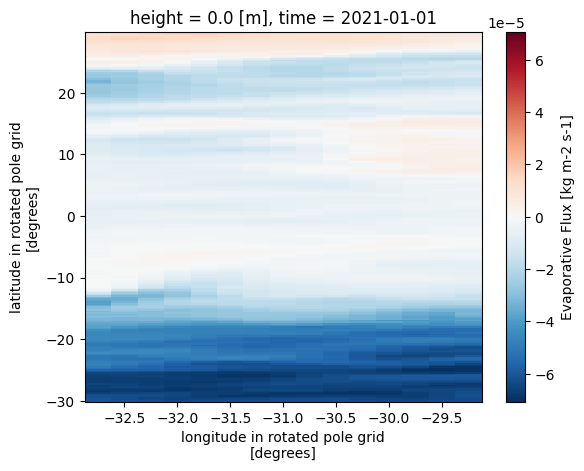

In [7]:
ds[var].isel(time=0).plot()

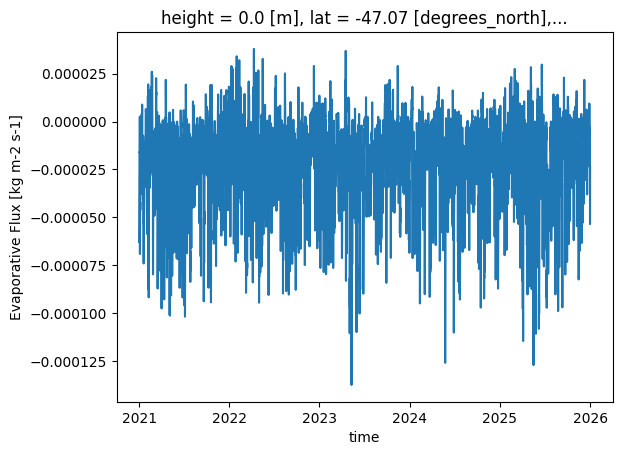

In [8]:
ds[var].isel(rlat=1,rlon=1).plot()

In [12]:
# check if adding h_surf to restart files is working

ds = xr.open_dataset("/home/nld4814/scratch/restart/run_FGRN055-era5_1939-2023/FGRN055_era5_initialize_from_2023_run_10002.nc")

ds

<xarray.Dataset> Size: 76kB
Dimensions:   (layer: 2366, constant: 1)
Dimensions without coordinates: layer, constant
Data variables:
    dens      (layer) float32 9kB ...
    temp      (layer) float32 9kB ...
    mass      (layer) float32 9kB ...
    depth     (layer) float32 9kB ...
    lwc       (layer) float32 9kB ...
    year      (layer) float32 9kB ...
    refreeze  (layer) float32 9kB ...
    denrho    (layer) float32 9kB ...
    prev_nt   (constant) float32 4B ...
    h_surf    (constant) float32 4B ...

In [13]:
ds.h_surf.values

array([0.04170471], dtype=float32)